# Visualizer
In this project step, the prepared data are inspected. 



In [57]:
# Import libraries
import logging
from pathlib import Path
from io import StringIO
import pandas as pd
from datetime import datetime

In [58]:
# Setup logger
def setup_logger():
    # Create logger instance
    logger = logging.getLogger(__name__)
    logger.setLevel(logging.INFO)

    # Clear existing, avoid duplicate logs
    if logger.hasHandlers():
        logger.handlers.clear()
    
    # Create FileHandler in overrite mode
    file_handler = logging.FileHandler('lognotebooks.log', mode ='w')

    # Set format
    formatter = logging.Formatter('%(asctime)s - %(levelno)s - %(lineno)d - %(module)s - %(message)s')
    file_handler.setFormatter(formatter)

    # Add FileHandler to logger
    logger.addHandler(file_handler)

    return logger

In [59]:
logger = setup_logger()
def inspect_raw_data(df, output_path=None):
    '''
    Inspect a DataFrame and save info to a text file.
    Parameters:
    df : pandas DataFrame
    output_path : Path or str, optional
        Where to save the output file. If None and save_to_file is True,
        will use current directory
    '''

    # Set display options
    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', None)
    
    # Prepare the information
    info_text = []
    info_text.append(f"Generated on: {datetime.now()}")
    info_text.append(f"Shape: {df.shape}")
    
    # Get info in string format
    buffer = StringIO()
    df.info(buf=buffer)
    info_text.append(f"\nDataFrame Info:")
    info_text.append(buffer.getvalue())

    # Add first 5 rows
    buffer_head = StringIO()
    df.head().to_string(buf=buffer_head)
    info_text.append(f"\nFirst 5 rows:")
    info_text.append(buffer_head.getvalue())

    # Add last 5 rows
    buffer_tail = StringIO()
    df.tail().to_string(buf=buffer_tail)
    info_text.append(f"\nLast 5 rows:")
    info_text.append(buffer_tail.getvalue())
    
    # Join all information
    full_report = '\n'.join(info_text)
    output_path = Path(output_path)
    output_path.write_text(full_report)
    logger.info(f"Report saved to: {output_path}")
    
    return full_report

In [60]:
logger = setup_logger()

# Define data path
data_path = Path('..') / '..' / 'data' / 'processed' / 'DataPrep' 
for file in data_path.glob('*.csv'):
    logger.info(f'Available csv file: {file.name}')

# Read in data
df_eso = pd.read_csv(data_path / 'merged_eso_data.csv', delimiter=',', parse_dates=['ID']) #, parse_dates=['ID']
df_smard = pd.read_csv(data_path / 'merged_smard_data.csv', delimiter=',', parse_dates=['ID']) #, parse_dates=['ID']

eso = 'eso'; smard = 'smard'
inspect_raw_data(df_eso, output_path=Path(f'{data_path}/../Visualizer/{eso}_inspection.txt'))
inspect_raw_data(df_smard, output_path=Path(f'{data_path}/../Visualizer/{smard}_inspection.txt'))

"Generated on: 2024-11-17 20:24:13.279662\nShape: (129767, 66)\n\nDataFrame Info:\n<class 'pandas.core.frame.DataFrame'>\nRangeIndex: 129767 entries, 0 to 129766\nData columns (total 66 columns):\n #   Column                                                    Non-Null Count   Dtype         \n---  ------                                                    --------------   -----         \n 0   ID                                                        129767 non-null  datetime64[ns]\n 1   Stromfluss_Nettoexport [MWh]                              129767 non-null  float64       \n 2   Stromfluss_Niederlande (Export) [MWh]                     129767 non-null  float64       \n 3   Stromfluss_Niederlande (Import) [MWh]                     129767 non-null  float64       \n 4   Stromfluss_Schweiz (Export) [MWh]                         129767 non-null  float64       \n 5   Stromfluss_Schweiz (Import) [MWh]                         129767 non-null  float64       \n 6   Stromfluss_Dänemark (Export) [

# Compare the features of the data
Check eso_inspection.txt and smard_inspection.txt in the 'processed' directory.
The table shows the features that are manually assignable at the first check.

                                               
| UK         | German (DE)                                                      |
|------------|------------------------------------------------------------------|
| Power Generation by Source:                                                   |
| GAS        | Erzeugung_Erdgas [MWh]                                           |
| COAL       | Erzeugung_Steinkohle [MWh] + Erzeugung_Braunkohle [MWh]          |
| NUCLEAR    | Erzeugung_Kernenergie [MWh]                                      |
| WIND       | Erzeugung_Wind Offshore [MWh] + Erzeugung_Wind Onshore [MWh]     |
| HYDRO      | Erzeugung_Wasserkraft [MWh]                                      |
| BIOMASS    | Erzeugung_Biomasse [MWh]                                         |
| SOLAR      | Erzeugung_Photovoltaik [MWh]                                     |
| STORAGE    | Erzeugung_Pumpspeicher [MWh]                                     |
| Demand/Load:                                                                  |
| ENGLAND_WALES_DEMAND  | Stromverbrauch_Gesamt (Netzlast) [MWh]                |
| PUMP_STORAGE_PUMPING  | Stromverbrauch_Pumpspeicher [MWh]                     |
| Cross-border flows (various interconnector flows):                            |          
| IFA_FLOW              | Stromfluss_Niederlande (Export/Import)                |
| BRITNED_FLOW          | Stromfluss_Frankreich (Export/Import)                 |
| MOYLE_FLOW            | Stromfluss_Polen (Export/Import)                      |
| etc.                  | etc.                                                  |
| System Balancing:                                                             |
| Energy Imbalance          |  Ausgleichsenergie_Volumen (+/-) [MWh]            |
| Frequency Control         |  Sekund_Abgerufene Menge (+/-) [MWh]              |
| Positive/Negative Reserve |   Minutenreserve_Abgerufene Menge (+/-) [MWh]     |


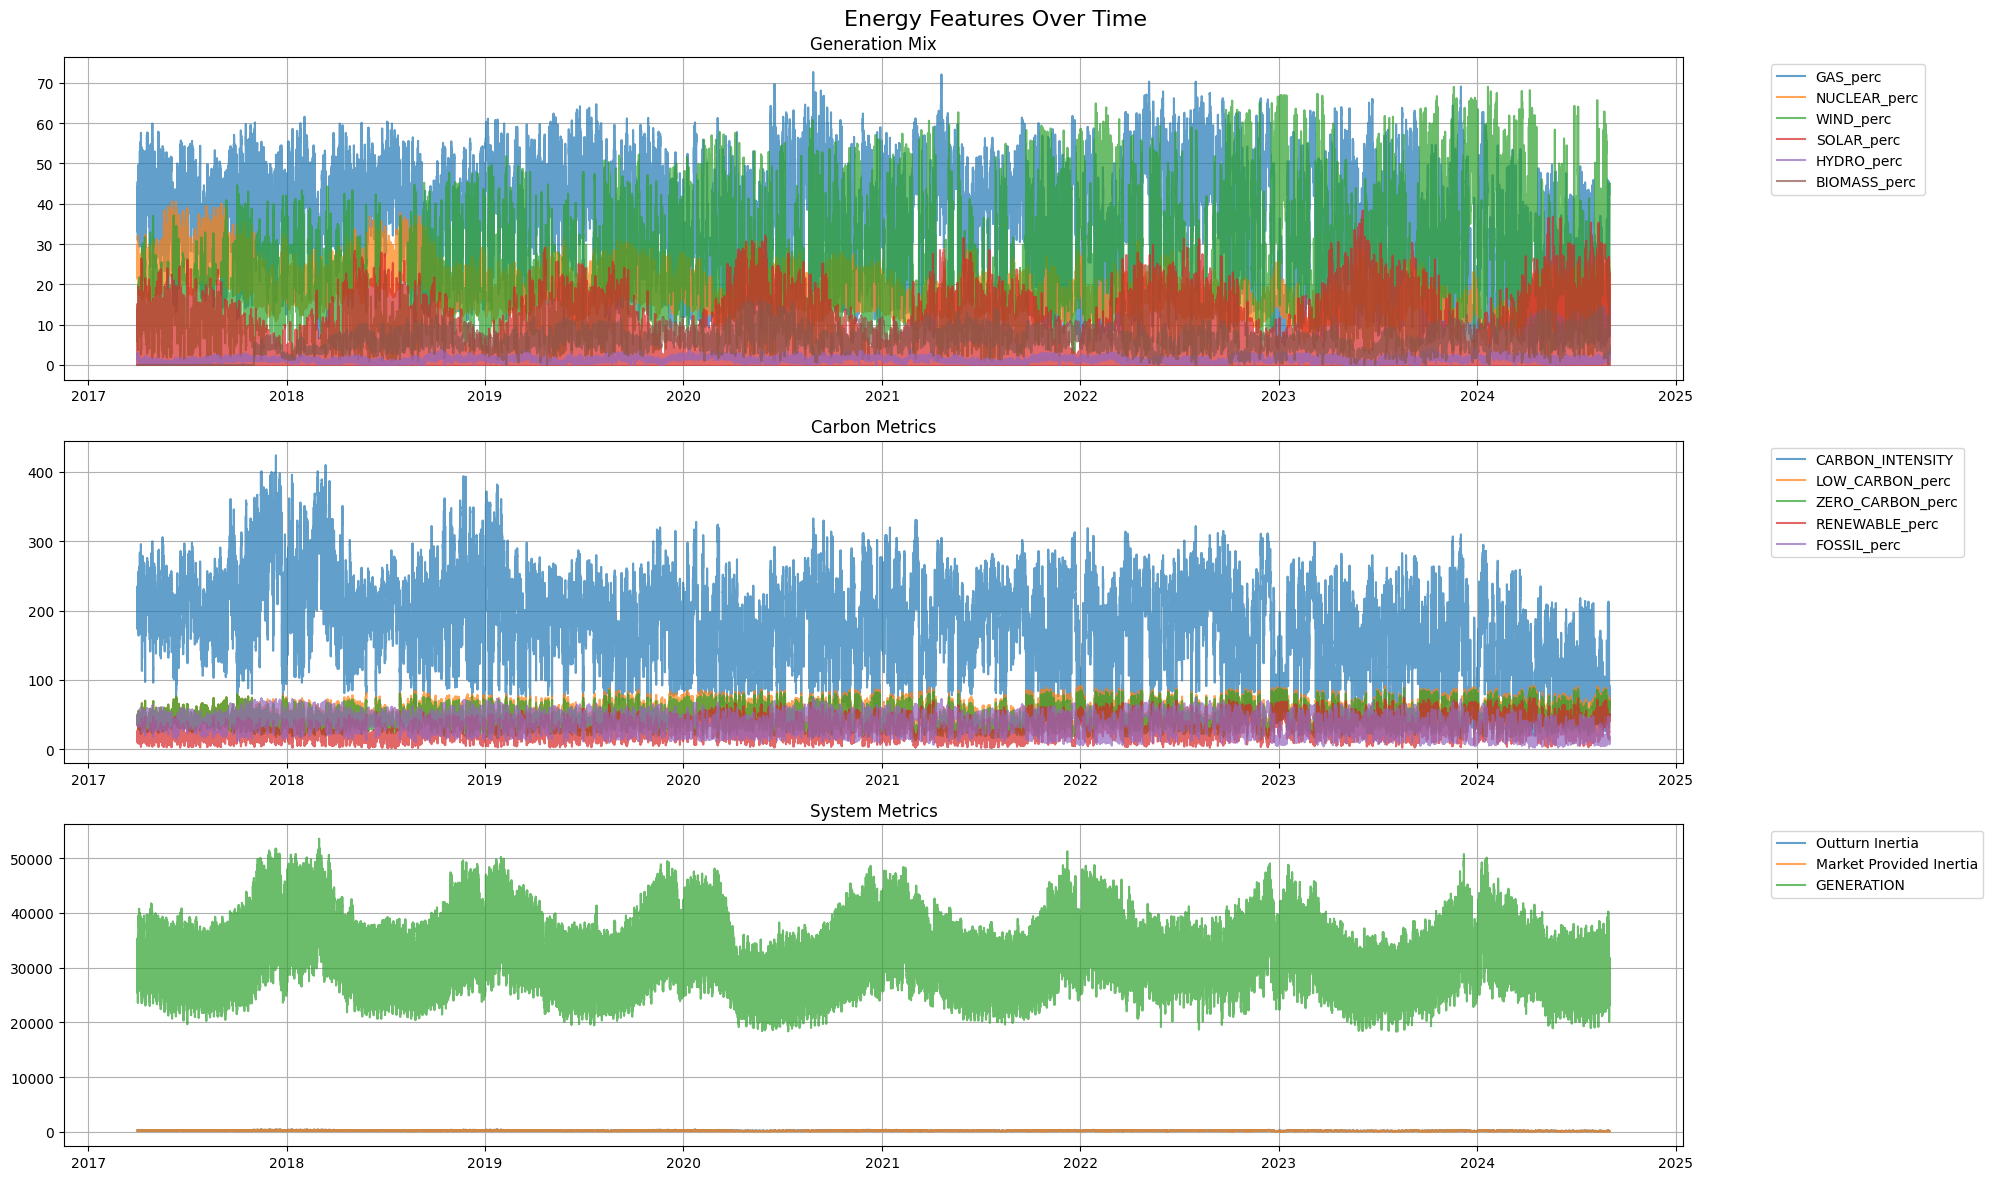

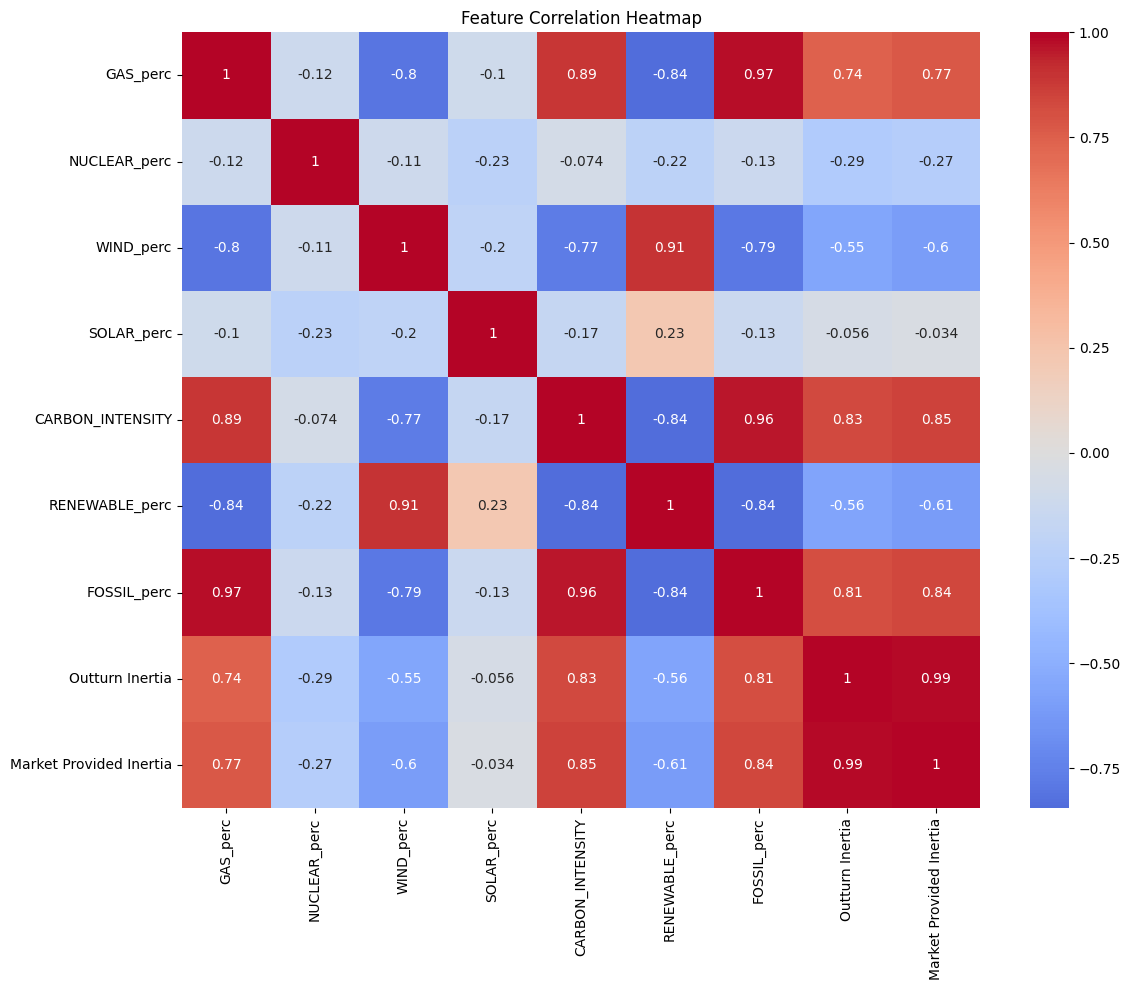

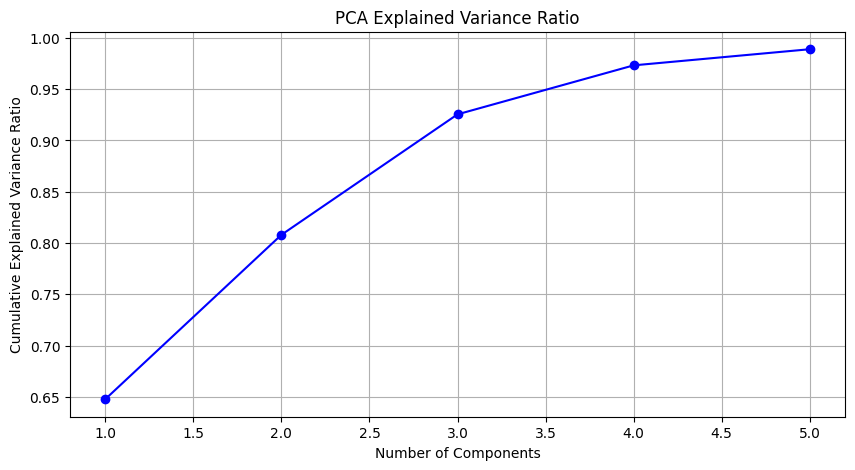

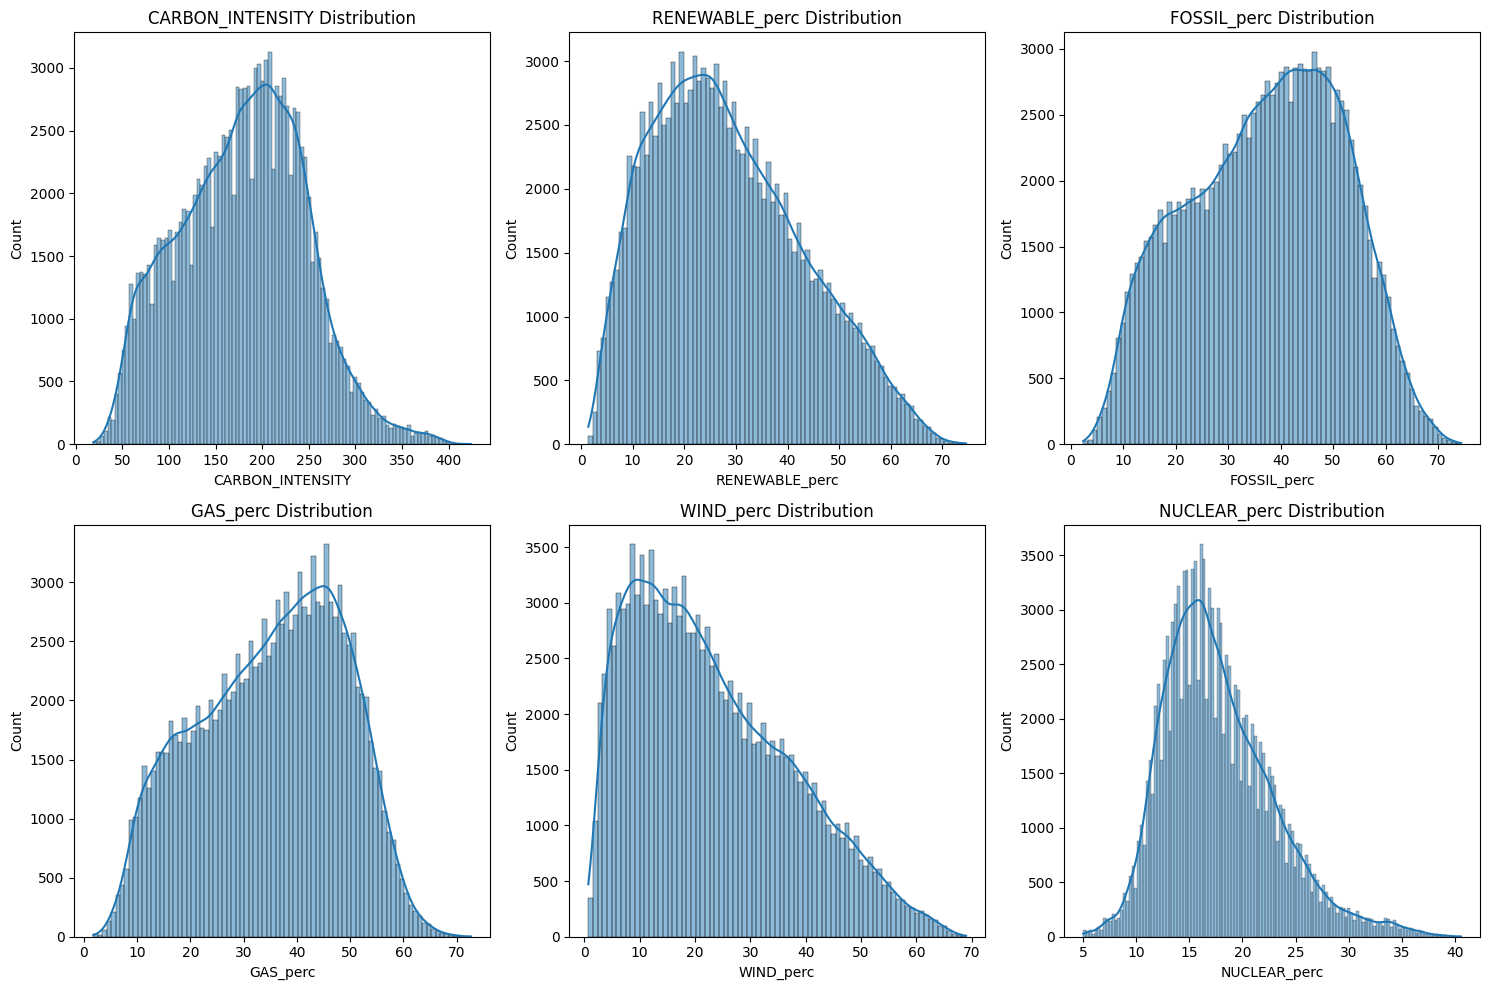

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def plot_feature_categories(df, figsize=(20, 12)):
    """
    Plot different categories of features over time
    """
    # Define feature categories
    categories = {
        'Generation Mix': ['GAS_perc', 'NUCLEAR_perc', 'WIND_perc', 'SOLAR_perc', 
                         'HYDRO_perc', 'BIOMASS_perc'],
        'Carbon Metrics': ['CARBON_INTENSITY', 'LOW_CARBON_perc', 'ZERO_CARBON_perc', 
                          'RENEWABLE_perc', 'FOSSIL_perc'],
        'System Metrics': ['Outturn Inertia', 'Market Provided Inertia', 'GENERATION']
    }
    
    # Create subplots for each category
    fig, axes = plt.subplots(len(categories), 1, figsize=figsize)
    fig.suptitle('Energy Features Over Time', fontsize=16)
    
    for idx, (category, features) in enumerate(categories.items()):
        for feature in features:
            axes[idx].plot(df.index, df[feature], label=feature, alpha=0.7)
        axes[idx].set_title(category)
        axes[idx].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        axes[idx].grid(True)
    
    plt.tight_layout()
    plt.show()

def plot_correlation_heatmap(df, features_to_analyze, figsize=(12, 10)):
    """
    Plot correlation heatmap for selected features
    """
    plt.figure(figsize=figsize)
    correlation_matrix = df[features_to_analyze].corr()
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
    plt.title('Feature Correlation Heatmap')
    plt.tight_layout()
    plt.show()

def plot_pca_analysis(df, features_to_analyze, n_components=2):
    """
    Perform and plot PCA analysis
    """
    # Standardize the features
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(df[features_to_analyze])
    
    # Perform PCA
    pca = PCA(n_components=n_components)
    pca_result = pca.fit_transform(scaled_data)
    
    # Plot explained variance ratio
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, n_components + 1), 
            np.cumsum(pca.explained_variance_ratio_), 
            'bo-')
    plt.xlabel('Number of Components')
    plt.ylabel('Cumulative Explained Variance Ratio')
    plt.title('PCA Explained Variance Ratio')
    plt.grid(True)
    plt.show()
    
    return pca_result, pca.explained_variance_ratio_

def plot_feature_distributions(df, features, figsize=(15, 10)):
    """
    Plot distribution of selected features
    """
    n_features = len(features)
    n_cols = 3
    n_rows = (n_features + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.ravel()
    
    for idx, feature in enumerate(features):
        sns.histplot(data=df, x=feature, ax=axes[idx], kde=True)
        axes[idx].set_title(f'{feature} Distribution')
    
    # Remove empty subplots
    for idx in range(len(features), len(axes)):
        fig.delaxes(axes[idx])
    
    plt.tight_layout()
    plt.show()

# Example usage:
def visualize_energy_data(df):
    """
    Main function to create all visualizations
    """
    # Create a copy of the DataFrame to avoid modifying the original
    df_vis = df.copy()
    
    # Set ID as index if it's not already
    if 'ID' in df_vis.columns:
        df_vis.set_index('ID', inplace=True)
    
    # 1. Plot time series for different categories
    plot_feature_categories(df_vis)
    
    # 2. Select important features for correlation analysis
    important_features = [
        'GAS_perc', 'NUCLEAR_perc', 'WIND_perc', 'SOLAR_perc',
        'CARBON_INTENSITY', 'RENEWABLE_perc', 'FOSSIL_perc',
        'Outturn Inertia', 'Market Provided Inertia'
    ]
    plot_correlation_heatmap(df_vis, important_features)
    
    # 3. PCA Analysis
    pca_result, explained_variance = plot_pca_analysis(df_vis, important_features, n_components=5)
    
    # 4. Distribution plots
    key_features = ['CARBON_INTENSITY', 'RENEWABLE_perc', 'FOSSIL_perc', 
                   'GAS_perc', 'WIND_perc', 'NUCLEAR_perc']
    plot_feature_distributions(df_vis, key_features)

# Usage example:
# visualize_energy_data(df)

visualize_energy_data(df_eso)
visualize_energy_data(df_eso)